# 14 — PINN forward and inverse solves (physicsnemo.sym)

`physicsnemo.sym` (bundled — no extra install) evaluates SymPy-defined PDE
residuals differentiably. This example runs `PinnSolveProcess` both ways:

1. **Forward**: solve the Laplace equation on a node cloud from nothing but
   the model part's Dirichlet data (fixed DOFs) — no training data, no mesh
   assembly; the physics residual and boundary loss train a coordinate MLP.
2. **Inverse**: recover an unknown diffusion coefficient from field
   observations — the coefficient is a trainable scalar fed to the PDE,
   with the physics gradients detached from the observed field.

In [1]:
import numpy
import matplotlib.pyplot as plt

import KratosMultiphysics as Kratos
import KratosMultiphysics.PhysicsNeMoApplication  # registers the application
from KratosMultiphysics.PhysicsNeMoApplication.processes.inference import pinn_solve_process

def harmonic(node):
    return node.X + 2.0 * node.Y - node.Z  # Laplace(u) = 0

def make_model_part(model, divisions=4):
    model_part = model.CreateModelPart("Domain")
    model_part.AddNodalSolutionStepVariable(Kratos.TEMPERATURE)
    model_part.AddNodalSolutionStepVariable(Kratos.NODAL_PAUX)
    node_id = 0
    for i in range(divisions + 1):
        for j in range(divisions + 1):
            for k in range(divisions + 1):
                node_id += 1
                model_part.CreateNewNode(
                    node_id, i / divisions, j / divisions, k / divisions)
    return model_part

 |  /           |                  
 ' /   __| _` | __|  _ \   __|    
 . \  |   (   | |   (   |\__ \  
_|\_\_|  \__,_|\__|\___/ ____/
           Multi-Physics 10.4."2"-physicsnemo-application-e03638205c2-Release-x86_64
           Compiled for GNU/Linux and Python3.12 with GCC-13.3
Compiled with threading and MPI support. Threading support with OpenMP.
Maximum number of threads: 2.
Running without MPI.
Importing    KratosPhysicsNeMoApplication 
 ______  _                _            ______        ______                           _ _                 _            
(_____ \| |              (_)          |  ___ \      |  ___ \         /\              | (_)           _   (_)            
 _____) ) | _  _   _  ___ _  ____  ___| |   | | ____| | _ | | ___   /  \  ____  ____ | |_  ____ ____| |_  _  ___  ____  
|  ____/| || \| | | |/___) |/ ___)/___) |   | |/ _  ) || || |/ _ \ / /\ \|  _ \|  _ \| | |/ ___) _  |  _)| |/ _ \|  _ \
| |     | | | | |_| |___ | ( (___|___ | |   | ( (/ /| || || | |_| | |

## Forward: Laplace from Dirichlet data alone

Boundary nodes are fixed at the harmonic field `u = x + 2y − z`; the
interior is unknown. The PDE + boundary data determine the solution, and
the PINN recovers it without a single labeled interior sample.

/home/vicente/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/home/vicente/.local/lib/python3.12/site-packages/torch/autograd/graph.py:979: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:408.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


loss: 1.907e+01 -> 1.036e-04
max |error| vs the analytic harmonic solution: 5.109e-03


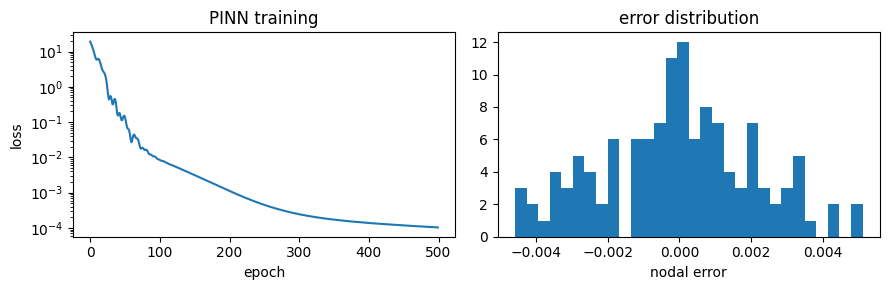

In [2]:
model = Kratos.Model()
domain = make_model_part(model)
for node in domain.Nodes:
    if any(abs(v) < 1e-12 or abs(v - 1.0) < 1e-12 for v in (node.X, node.Y, node.Z)):
        node.Fix(Kratos.TEMPERATURE)
        node.SetSolutionStepValue(Kratos.TEMPERATURE, harmonic(node))

forward = pinn_solve_process.Factory(Kratos.Parameters("""{
    "Parameters": {
        "model_part_name" : "Domain",
        "mode"            : "forward",
        "physics"         : { "pde" : "builtin:diffusion", "pde_arguments" : { "D" : 1.0 } },
        "solution_fields" : [ { "variable_name" : "TEMPERATURE", "data_location" : "node_historical" } ],
        "output_fields"   : [ { "variable_name" : "TEMPERATURE", "data_location" : "node_historical" } ],
        "network"         : { "layer_size" : 32, "num_layers" : 3 },
        "training"        : { "epochs" : 500, "learning_rate" : 5e-3, "boundary_weight" : 10.0, "seed" : 0 },
        "device"          : "auto",
        "normalize_coordinates" : false
    }
}"""), model)
forward.ExecuteBeforeSolutionLoop()

errors = numpy.array([
    node.GetSolutionStepValue(Kratos.TEMPERATURE) - harmonic(node) for node in domain.Nodes])
print(f"loss: {forward.loss_history[0]:.3e} -> {forward.loss_history[-1]:.3e}")
print(f"max |error| vs the analytic harmonic solution: {numpy.abs(errors).max():.3e}")

fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].semilogy(forward.loss_history)
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss"); axes[0].set_title("PINN training")
axes[1].hist(errors, bins=30)
axes[1].set_xlabel("nodal error"); axes[1].set_title("error distribution")
plt.tight_layout(); plt.show()
assert numpy.abs(errors).max() < 0.2

### The solution on the nodes

The PINN's temperature on the collocation nodes (the model part has nodes only, no elements: this is a mesh-free solve) and its error against the harmonic solution, rendered with pyvista.

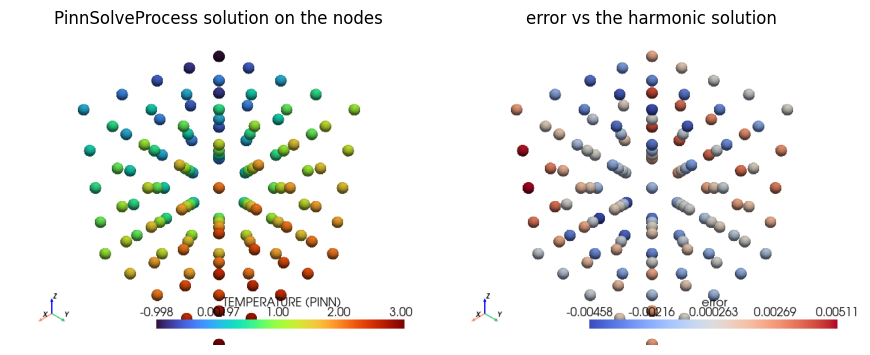

In [3]:
import pyvista as pv
from KratosMultiphysics import pyvista_utilities as pv_utils

def render_points(points, values, title, cmap="turbo", clim=None, point_size=14, view="iso"):
    """Off-screen pyvista render of a point cloud coloured by a scalar (numpy image)."""
    cloud = pv.PolyData(numpy.asarray(points, dtype=float))
    cloud["value"] = numpy.asarray(values, dtype=float).ravel()
    plotter = pv.Plotter(off_screen=True, window_size=(640, 480))
    plotter.add_points(cloud, scalars="value", cmap=cmap, clim=clim, point_size=point_size,
                       render_points_as_spheres=True, scalar_bar_args={"title": title})
    plotter.add_axes()
    plotter.view_xy() if view == "xy" else plotter.view_isometric()
    return plotter.screenshot(None)

from pathlib import Path
Path("output").mkdir(exist_ok=True)
points = numpy.array([[n.X, n.Y, n.Z] for n in domain.Nodes])
temperature = [n.GetSolutionStepValue(Kratos.TEMPERATURE) for n in domain.Nodes]
img_t = render_points(points, temperature, "TEMPERATURE (PINN)", point_size=18)
img_e = render_points(points, errors, "error", cmap="coolwarm", point_size=18)
fig, axes = plt.subplots(1, 2, figsize=(8.8, 4.0))
for ax, (img, title) in zip(numpy.atleast_1d(axes), [(img_t, 'PinnSolveProcess solution on the nodes'), (img_e, 'error vs the harmonic solution')]):
    ax.imshow(img); ax.set_title(title); ax.axis("off")
plt.tight_layout(); plt.savefig('output/pinn_nodes.png', dpi=120, bbox_inches="tight"); plt.show()


## Inverse: recovering a diffusion coefficient

Observations `u = x² + y² + z²` obey `-D lap(u) + 6 = 0` exactly at
`D = 1`. The coefficient enters the PDE as a spatial input (`"D": null`),
a trainable scalar starts at 0.3, the field network fits the observations,
and `detach_names` (generated automatically) keeps the physics loss from
touching the field — only `D` feels it.

In [4]:
for node in domain.Nodes:
    node.SetSolutionStepValue(Kratos.NODAL_PAUX, node.X**2 + node.Y**2 + node.Z**2)

inverse = pinn_solve_process.Factory(Kratos.Parameters("""{
    "Parameters": {
        "model_part_name"    : "Domain",
        "mode"               : "inverse",
        "physics"            : { "pde" : "builtin:diffusion", "pde_arguments" : { "D" : null, "source" : -6.0 } },
        "inverse_parameters" : { "D" : 0.3 },
        "observation_fields" : [ { "variable_name" : "NODAL_PAUX", "data_location" : "node_historical" } ],
        "network"            : { "layer_size" : 32, "num_layers" : 3 },
        "training"           : { "epochs" : 500, "learning_rate" : 1e-2, "data_weight" : 20.0, "seed" : 0 },
        "device"             : "auto",
        "normalize_coordinates" : false
    }
}"""), model)
inverse.Solve()

recovered = inverse.inverse_values["D"]
print(f"recovered D = {recovered:.4f} (true value: 1.0)")
assert abs(recovered - 1.0) < 0.2

PinnSolveProcess: recovered coefficients: {'D': 1.0190566778182983} 
recovered D = 1.0191 (true value: 1.0)


/home/vicente/src/Kratos/bin/Release/KratosMultiphysics/PhysicsNeMoApplication/processes/inference/pinn_solve_process.py:327: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:822.)
  self.inverse_values = {name: float(tensor) for name, tensor in inverse_tensors.items()}


## Takeaways

- The physics layer is fully data-free on the forward path: Dirichlet
  fixities on the model part are the only inputs, exactly as a solver
  would see them.
- The same `physics_informed` machinery plugs into surrogate training as
  an extra loss term (`TrainModel(..., extra_loss_terms=[...])`) — see the
  Physics Informed documentation page.
- The inverse mechanism (trainable coefficients as spatial PDE inputs,
  detached field gradients) is upstream's documented recipe;
  `SystemIdentificationApplication` is the classical adjoint baseline.
- PINN convergence is stochastic: seed the training block and prefer
  loss-drop / loose-tolerance assertions in automated tests.